In [8]:
import os
import re
import threading
import time
from concurrent.futures import ThreadPoolExecutor

from bs4 import BeautifulSoup
from IPython.display import FileLink
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 120

In [9]:
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML,"
        " like Gecko) Chrome/120.0.0.0 Safari/537.36"
    ),
    "Accept-Encoding": "gzip, deflate",
}

BASE_CATALOG = "https://www.setneg.go.id/listcontent/listberita/pidato_presiden"
DOMAIN = "https://www.setneg.go.id"
OUTPUT_CSV = "/kaggle/working/presidential_speech_dataset.csv"

# Pola MBG
MBG_PATTERN = (
    r"\b("
    r"MBG|"
    r"Makan\s+Bergizi\s+Gratis|"
    r"Makan\s+Siang\s+Gratis|"
    r"Makanan\s+Bergizi(?:\s+Gratis)?|"
    r"Pemberian\s+Makanan\s+Bergizi|"
    r"Susu\s+Gratis|Nutrisi\s+Gratis|"
    r"Dapur\s+Umum\s+MBG|Satuan\s+Pelayanan\s+MBG|"
    r"Badan\s+Gizi\s+Nasional|BGN"
    r")\b"
)

# Set kata fungsi untuk klasifikasi bahasa tanpa library eksternal (sangat cepat & deterministik)
EN_STOPWORDS = {
    "the",
    "and",
    "of",
    "to",
    "in",
    "for",
    "is",
    "on",
    "that",
    "by",
    "this",
    "with",
    "we",
    "are",
    "at",
    "as",
    "our",
    "from",
}
ID_STOPWORDS = {
    "dan",
    "yang",
    "di",
    "ke",
    "dari",
    "untuk",
    "pada",
    "ini",
    "dengan",
    "itu",
    "kita",
    "adalah",
    "saya",
    "dalam",
    "akan",
    "juga",
    "bisa",
    "bapak",
    "ibu",
}


def detect_language(text):
  if not text or len(text.strip()) == 0:
    return "unknown"
  words = set(re.findall(r"\b[a-zA-Z]{2,}\b", text.lower()[:1500]))
  score_en = len(words.intersection(EN_STOPWORDS))
  score_id = len(words.intersection(ID_STOPWORDS))

  if score_en > score_id:
    return "en"
  elif score_id > score_en:
    return "id"
  return "id"  # default fallback konteks Setneg


# Thread-local session
thread_local = threading.local()


def get_session():
  if not hasattr(thread_local, "session"):
    thread_local.session = requests.Session()
    thread_local.session.headers.update(HEADERS)
  return thread_local.session

In [16]:
def crawl_speech_urls(step_offset=10):
  urls = []
  seen = set()
  offset = 0
  consecutive_empty = 0

  print("Menelusuri daftar arsip pidato...")

  while True:
    url = f"{BASE_CATALOG}/{offset}" if offset > 0 else BASE_CATALOG
    try:
      resp = requests.get(url, headers=HEADERS, timeout=10)
      if resp.status_code != 200:
        break

      soup = BeautifulSoup(resp.text, "html.parser")
      links = soup.select("h4.media-heading a, h6.media-heading a")

      if not links:
        consecutive_empty += 1
        if consecutive_empty >= 2:
          break
        offset += step_offset
        continue

      consecutive_empty = 0
      new_items = 0

      for a in links:
        href = a.get("href", "").strip()
        if href and "/baca/index/" in href:
          if not href.startswith("http"):
            href = DOMAIN + href
          if href not in seen:
            seen.add(href)
            urls.append(href)
            new_items += 1

      if offset % 200 == 0:
        print(f"Offset {offset:4d} | Terkumpul: {len(urls)} URL")

      if new_items == 0 and len(links) > 0:
        break

      offset += step_offset
      time.sleep(0.1)

    except requests.RequestException:
      time.sleep(1)
      offset += step_offset

  return urls


# Muat dari cache lokal jika ada, atau jalankan crawler
CACHE_URL_FILE = "all_speech_urls.txt"

# Cek apakah file ada dan isinya lengkap (minimal 2000 URL)
if os.path.exists(CACHE_URL_FILE):
  with open(CACHE_URL_FILE, "r", encoding="utf-8") as f:
    speech_urls = [line.strip() for line in f if line.strip()]

  if len(speech_urls) < 2000:
    print(
        f"File cache hanya berisi {len(speech_urls)} URL (belum lengkap)."
        " Menjalankan crawling ulang..."
    )
    speech_urls = crawl_speech_urls()
    with open(CACHE_URL_FILE, "w", encoding="utf-8") as f:
      f.write("\n".join(speech_urls))
  else:
    print(f"Memuat {len(speech_urls)} URL dari {CACHE_URL_FILE}")
else:
  speech_urls = crawl_speech_urls()
  with open(CACHE_URL_FILE, "w", encoding="utf-8") as f:
    f.write("\n".join(speech_urls))

print(f"Selesai! Total {len(speech_urls)} URL siap diekstrak.")

File cache hanya berisi 30 URL (belum lengkap). Menjalankan crawling ulang...
Menelusuri daftar arsip pidato...
Offset    0 | Terkumpul: 10 URL
Offset  200 | Terkumpul: 210 URL
Offset  400 | Terkumpul: 410 URL
Offset  600 | Terkumpul: 610 URL
Offset  800 | Terkumpul: 810 URL
Offset 1000 | Terkumpul: 1010 URL
Offset 1200 | Terkumpul: 1210 URL
Offset 1400 | Terkumpul: 1409 URL
Offset 1600 | Terkumpul: 1607 URL
Offset 1800 | Terkumpul: 1806 URL
Offset 2000 | Terkumpul: 1998 URL
Offset 2200 | Terkumpul: 2196 URL
Offset 2400 | Terkumpul: 2396 URL
Offset 2600 | Terkumpul: 2590 URL
Offset 2800 | Terkumpul: 2787 URL
Selesai! Total 2972 URL siap diekstrak.


In [19]:
def parse_speech_detail(url):
  session = get_session()
  try:
    resp = session.get(url, timeout=8)
    if resp.status_code != 200:
      return None

    soup = BeautifulSoup(resp.content, "lxml")

    # Judul
    tag_title = soup.find("h1", id="title-page")
    if not tag_title:
      return None
    title = tag_title.get_text(strip=True)

    # Tanggal dan total views
    release_date = None
    views_count = 0
    tag_meta = soup.find("p", class_="widget-metas")
    if tag_meta:
      lines = [
          line.strip()
          for line in tag_meta.get_text("\n", strip=True).split("\n")
          if line.strip()
      ]
      if lines:
        release_date = lines[0]
      views_match = re.search(r"Di\s*baca\s*(\d+)\s*kali", tag_meta.text, re.I)
      if views_match:
        views_count = int(views_match.group(1))

    # Lokasi
    location = "Unspecified"
    place_div = soup.find("div", class_="place")
    if place_div:
      location = place_div.get_text(strip=True)
    else:
      hr_tag = soup.find("hr")
      if hr_tag:
        prev_p = hr_tag.find_previous("p")
        if prev_p and "di " in prev_p.text.lower():
          location = prev_p.get_text(strip=True)

    # Isi teks naskah
    content_div = soup.find("div", class_="content")
    if content_div:
      paragraphs = [
          p.get_text(" ", strip=True)
          for p in content_div.find_all("p")
          if p.get_text(strip=True)
      ]
      # Fallback jika tidak ada tag <p>
      if not paragraphs:
        paragraphs = [
            line.strip()
            for line in content_div.get_text("\n", strip=True).split("\n")
            if line.strip()
        ]
    else:
      main_sec = soup.find("section")
      if main_sec:
        for tag in main_sec(["script", "style", "table", "form", "nav"]):
          tag.decompose()
        paragraphs = [
            p.get_text(" ", strip=True)
            for p in main_sec.find_all("p")
            if p.get_text(strip=True)
            and "widget-metas" not in p.get("class", [])
            and "bagikan berita" not in p.text.lower()
        ]
      else:
        paragraphs = []

    content_text = " ".join(paragraphs)

    # Ekstraksi metrik & bahasa
    title_word_count = len(title.split())
    content_word_count = len(content_text.split())
    mbg_mention_count = len(re.findall(MBG_PATTERN, content_text, re.I))
    lang = detect_language(f"{title} {content_text}")

    return {
        "title": title,
        "release_date": release_date,
        "location": location,
        "views_count": views_count,
        "language": lang,
        "title_word_count": title_word_count,
        "content_word_count": content_word_count,
        "mbg_mention_count": mbg_mention_count,
        "content_text": content_text,
        "url": url,
    }
  except Exception:
    return None

In [20]:
# Cek file eksisting untuk mencegah scraping ulang yang tidak disengaja
urls_to_scrape = speech_urls
df_existing = None

if os.path.exists(OUTPUT_CSV):
  print(f"File '{OUTPUT_CSV}' sudah ada.")
  try:
    df_existing = pd.read_csv(OUTPUT_CSV)
    scraped_urls = set(df_existing["url"].dropna().unique())
    remaining_urls = [u for u in speech_urls if u not in scraped_urls]

    print(
        f"- Data tersimpan: {len(df_existing)} baris ({len(scraped_urls)} URL)"
    )
    print(f"- Sisa URL yang belum di-scrape: {len(remaining_urls)}")

    if not remaining_urls:
      print("Semua data telah selesai di-scrape. Lewati proses scraping.")
      urls_to_scrape = []
    else:
      print("Melanjutkan scraping hanya untuk URL yang belum selesai...")
      urls_to_scrape = remaining_urls
  except Exception as e:
    print(f"Gagal membaca file eksisting ({e}). Memulai ulang scraping.")
    df_existing = None

# Eksekusi scraping
if urls_to_scrape:
  print(
      f"Mengekstrak {len(urls_to_scrape)} naskah dengan 25 koneksi paralel..."
  )
  new_data = []

  with ThreadPoolExecutor(max_workers=25) as executor:
    for idx, item in enumerate(
        executor.map(parse_speech_detail, urls_to_scrape), start=1
    ):
      if item:
        new_data.append(item)
      if idx % 300 == 0 or idx == len(urls_to_scrape):
        print(f"Progres: {idx}/{len(urls_to_scrape)} selesai")

  df_new = pd.DataFrame(new_data)

  if df_existing is not None and not df_existing.empty:
    df_speech = pd.concat([df_existing, df_new], ignore_index=True)
  else:
    df_speech = df_new

  df_speech = df_speech.drop_duplicates(subset=["url"], keep="first")
  df_speech.to_csv(OUTPUT_CSV, index=False)
  print(f"Dataset berhasil disimpan: {len(df_speech)} baris di {OUTPUT_CSV}")
else:
  df_speech = df_existing

FileLink("presidential_speech_dataset.csv")

File '/kaggle/working/presidential_speech_dataset.csv' sudah ada.
- Data tersimpan: 29 baris (29 URL)
- Sisa URL yang belum di-scrape: 2943
Melanjutkan scraping hanya untuk URL yang belum selesai...
Mengekstrak 2943 naskah dengan 25 koneksi paralel...
Progres: 300/2943 selesai
Progres: 600/2943 selesai
Progres: 900/2943 selesai
Progres: 1200/2943 selesai
Progres: 1500/2943 selesai
Progres: 1800/2943 selesai
Progres: 2100/2943 selesai
Progres: 2400/2943 selesai
Progres: 2700/2943 selesai
Progres: 2943/2943 selesai
Dataset berhasil disimpan: 2872 baris di /kaggle/working/presidential_speech_dataset.csv


/kaggle/working/presidential_speech_dataset.csv

In [21]:
df_speech = pd.read_csv(OUTPUT_CSV)

# 1. Bersihkan Kolom Lokasi
df_speech["location"] = df_speech["location"].replace(
    r"^\s*Unspecified\s*$", np.nan, regex=True
)
df_speech["location"] = (
    df_speech["location"]
    .str.replace(r"(?i)^di\s+", "", regex=True)
    .str.strip()
)

# 2. Parsing Tanggal ke Datetime
month_mapping = {
    "jan": "01",
    "feb": "02",
    "mar": "03",
    "apr": "04",
    "mei": "05",
    "jun": "06",
    "jul": "07",
    "agu": "08",
    "sep": "09",
    "okt": "10",
    "nov": "11",
    "des": "12",
}

extracted_dates = df_speech["release_date"].astype(str).str.extract(
    r"(\d{1,2})\s+([A-Za-z]+)\s+(\d{4})"
)
month_numbers = extracted_dates[1].str.lower().str[:3].map(month_mapping)
formatted_dates = (
    extracted_dates[2]
    + "-"
    + month_numbers
    + "-"
    + extracted_dates[0].str.zfill(2)
)
df_speech["release_date"] = pd.to_datetime(formatted_dates, errors="coerce")

# 3. Klasifikasi Era Presiden
cutoffs = [
    pd.to_datetime("2004-10-20"),
    pd.to_datetime("2014-10-20"),
    pd.to_datetime("2024-10-20"),
    pd.to_datetime("2030-01-01"),
]
labels = ["Susilo Bambang Yudhoyono", "Joko Widodo", "Prabowo Subianto"]
df_speech["president_era"] = pd.cut(
    df_speech["release_date"], bins=cutoffs, labels=labels, right=False
)

# 4. Deteksi Wilayah / Negara
country_lookup = {
    r"\bindonesia\b": "Indonesia",
    r"\bmalaysia\b": "Malaysia",
    r"\bsingap(?:ura|ore)\b": "Singapura",
    r"\bbrunei\b": "Brunei Darussalam",
    r"\bthailand\b": "Thailand",
    r"\bfilipina\b|\bphilippines?\b": "Filipina",
    r"\bvietnam\b": "Vietnam",
    r"\bjepang\b|\bjapan\b": "Jepang",
    r"\btiongkok\b|\bchina\b|\brrt\b": "Tiongkok",
    r"\bkorea\b": "Korea Selatan",
    r"\bindia\b": "India",
    r"\barab saudi\b|\bsaudi arabia\b": "Arab Saudi",
    r"\b(?:persatuan )?emirat arab\b|\buni emirat arab\b|\buae\b|\bdubai\b": (
        "Uni Emirat Arab"
    ),
    r"\brusia\b|\brussia\b": "Rusia",
    r"\binggris(?: raya)?\b|\bunited kingdom\b|\buk\b": "Inggris",
    r"\bprancis\b|\bfrance\b": "Prancis",
    r"\bjerman\b|\bgermany\b": "Jerman",
    r"\bbelanda\b|\bnetherlands\b": "Belanda",
    r"\bswiss\b|\bswitzerland\b": "Swiss",
    r"\bturki(?:ye)?\b|\bturkey\b": "Turki",
    r"\bamerika(?: serikat)?\b|\bunited states(?: of america)?\b|\bu\.?s\.?a?\b": (
        "Amerika Serikat"
    ),
    r"\baustralia\b": "Australia",
    r"\bbra[sz]il\b": "Brasil",
}
indo_terms = (
    r"provinsi|kabupaten|kota|istana|jakarta|bogor|dki|diy|ikn|nusantara|jawa|"
    r"sumat[er]a|kalimantan|sulawesi|papua|bali|banten|lampung|aceh"
)


def map_country(loc):
  if pd.isna(loc):
    return np.nan
  s = str(loc).lower()
  for pat, name in country_lookup.items():
    if re.search(pat, s):
      return name
  if re.search(indo_terms, s):
    return "Indonesia"
  return "Internasional Lainnya"


df_speech["country"] = df_speech["location"].apply(map_country)

# Simpan data bersih siap EDA
df_speech.to_csv("/kaggle/working/presidential_speech_cleaned.csv", index=False)
display(
    df_speech[
        ["president_era", "language", "country", "content_word_count"]
    ].head()
)

,president_era,language,country,content_word_count
0,Prabowo Subianto,en,India,663
1,Prabowo Subianto,en,India,671
2,Prabowo Subianto,id,Indonesia,1487
3,Prabowo Subianto,id,Rusia,253
4,Prabowo Subianto,en,Rusia,2299


In [38]:
print(f"Dimensi Dataset: {df_speech.shape[0]} baris, {df_speech.shape[1]} kolom\n")
df_speech.info()
display(df_speech.head())

attribute_types = pd.DataFrame({
    "Atribut": df_speech.columns,
    "Dtype": df_speech.dtypes.values,
    "Tipe Atribut": [
        "Nominal (Teks)",
        "Interval (Waktu/Datetime)",
        "Nominal",
        "Numerik Diskrit",
        "Nominal (Kategorikal)",
        "Numerik Diskrit",
        "Numerik Diskrit",
        "Numerik Diskrit",
        "Nominal (Teks)",
        "Nominal (URL)",
        "Ordinal (Urutan Periode)",
        "Nominal (Geografis)"
    ]
})
display(attribute_types)

Dimensi Dataset: 2872 baris, 12 kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2872 entries, 0 to 2871
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   title               2872 non-null   object        
 1   release_date        2872 non-null   datetime64[ns]
 2   location            865 non-null    object        
 3   views_count         2872 non-null   int64         
 4   language            2872 non-null   object        
 5   title_word_count    2872 non-null   int64         
 6   content_word_count  2872 non-null   int64         
 7   mbg_mention_count   2872 non-null   int64         
 8   content_text        2739 non-null   object        
 9   url                 2872 non-null   object        
 10  president_era       2872 non-null   category      
 11  country             865 non-null    object        
dtypes: category(1), datetime64[ns](1), int64(4), object(6)
memory usa

,title,release_date,location,views_count,language,title_word_count,content_word_count,mbg_mention_count,content_text,url,president_era,country
0,Sambutan Presiden pada Sesi Terbuka Konferensi...,2026-09-13,"Bharat Mandapam, New Delhi, Republik India",5,en,11,663,0,"Your Excellency, Prime Minister Shri Narendra ...",https://www.setneg.go.id/baca/index/sambutan_p...,Prabowo Subianto,India
1,Sambutan Presiden pada Sesi Terbatas Konferens...,2026-09-12,"Bharat Mandapam, New Delhi, Republik India",5,en,11,671,0,"Excellency, Prime Minister Sri Narendra Modi; ...",https://www.setneg.go.id/baca/index/sambutan_p...,Prabowo Subianto,India
2,Sambutan Presiden pada Pelepasan Kontingen Ind...,2026-09-09,"Istana Negara, Jakarta",79,id,14,1487,0,Bismillahirrahmanirrahi m. Assalamualaikum war...,https://www.setneg.go.id/baca/index/sambutan_p...,Prabowo Subianto,Indonesia
3,Sambutan Presiden RI dalam Pertemuan Bilateral...,2026-09-03,"Vladivostok, Federasi Rusia",149,id,16,253,0,"di Vladivostok, Federasi Rusia Terima kasih Ya...",https://www.setneg.go.id/baca/index/sambutan_p...,Prabowo Subianto,Rusia
4,Pidato Presiden RI pada Eastern Economic Forum...,2026-09-03,"Plenary Hall, Far Eastern Federal University, ...",130,en,9,2299,0,Bismillahirrahmanirrahim. Assalamu’alaikum war...,https://www.setneg.go.id/baca/index/pidato_pre...,Prabowo Subianto,Rusia


,Atribut,Dtype,Tipe Atribut
0,title,object,Nominal (Teks)
1,release_date,datetime64[ns],Interval (Waktu/Datetime)
2,location,object,Nominal
3,views_count,int64,Numerik Diskrit
4,language,object,Nominal (Kategorikal)
5,title_word_count,int64,Numerik Diskrit
6,content_word_count,int64,Numerik Diskrit
7,mbg_mention_count,int64,Numerik Diskrit
8,content_text,object,Nominal (Teks)
9,url,object,Nominal (URL)


In [36]:
numeric_cols = ["views_count", "title_word_count", "content_word_count", "mbg_mention_count"]

stats = df_speech[numeric_cols].describe().T[["mean", "50%", "std", "min", "max"]]
stats.rename(columns={"50%": "median"}, inplace=True)
stats["mode"] = df_speech[numeric_cols].mode().iloc[0]
display(stats[["mean", "median", "mode", "std", "min", "max"]])

for col in ["president_era", "language"]:
    freq = df_speech[col].value_counts(dropna=False).to_frame("Frekuensi")
    freq["Persen (%)"] = (freq["Frekuensi"] / len(df_speech) * 100).round(2)
    display(freq)

missing = pd.DataFrame({
    "Missing Count": df_speech.isnull().sum(),
    "Persen (%)": (df_speech.isnull().sum() / len(df_speech) * 100).round(2)
})
display(missing)

outlier_data = []
for col in numeric_cols:
    q1 = df_speech[col].quantile(0.25)
    q3 = df_speech[col].quantile(0.75)
    iqr = q3 - q1
    outlier_count = len(df_speech[(df_speech[col] < q1 - 1.5 * iqr) | (df_speech[col] > q3 + 1.5 * iqr)])
    outlier_data.append({
        "Atribut": col,
        "Jumlah Outlier": outlier_count,
        "Persentase (%)": round(outlier_count / len(df_speech) * 100, 2)
    })

display(pd.DataFrame(outlier_data))

,mean,median,mode,std,min,max
views_count,1848.137535,1583.5,1758,1233.218987,5.0,29831.0
title_word_count,12.896588,13.0,13,3.010043,3.0,37.0
content_word_count,1130.971448,697.0,0,1220.744243,0.0,12704.0
mbg_mention_count,0.075557,0.0,0,0.821304,0.0,18.0


,Frekuensi,Persen (%)
president_era,,
Joko Widodo,1534,53.41
Susilo Bambang Yudhoyono,1107,38.54
Prabowo Subianto,231,8.04


,Frekuensi,Persen (%)
language,,
id,2736,95.26
en,136,4.74


,Missing Count,Persen (%)
title,0,0.00
release_date,0,0.00
location,2007,69.88
views_count,0,0.00
language,0,0.00
title_word_count,0,0.00
content_word_count,0,0.00
mbg_mention_count,0,0.00
content_text,133,4.63
url,0,0.00


,Atribut,Jumlah Outlier,Persentase (%)
0,views_count,214,7.45
1,title_word_count,41,1.43
2,content_word_count,162,5.64
3,mbg_mention_count,41,1.43


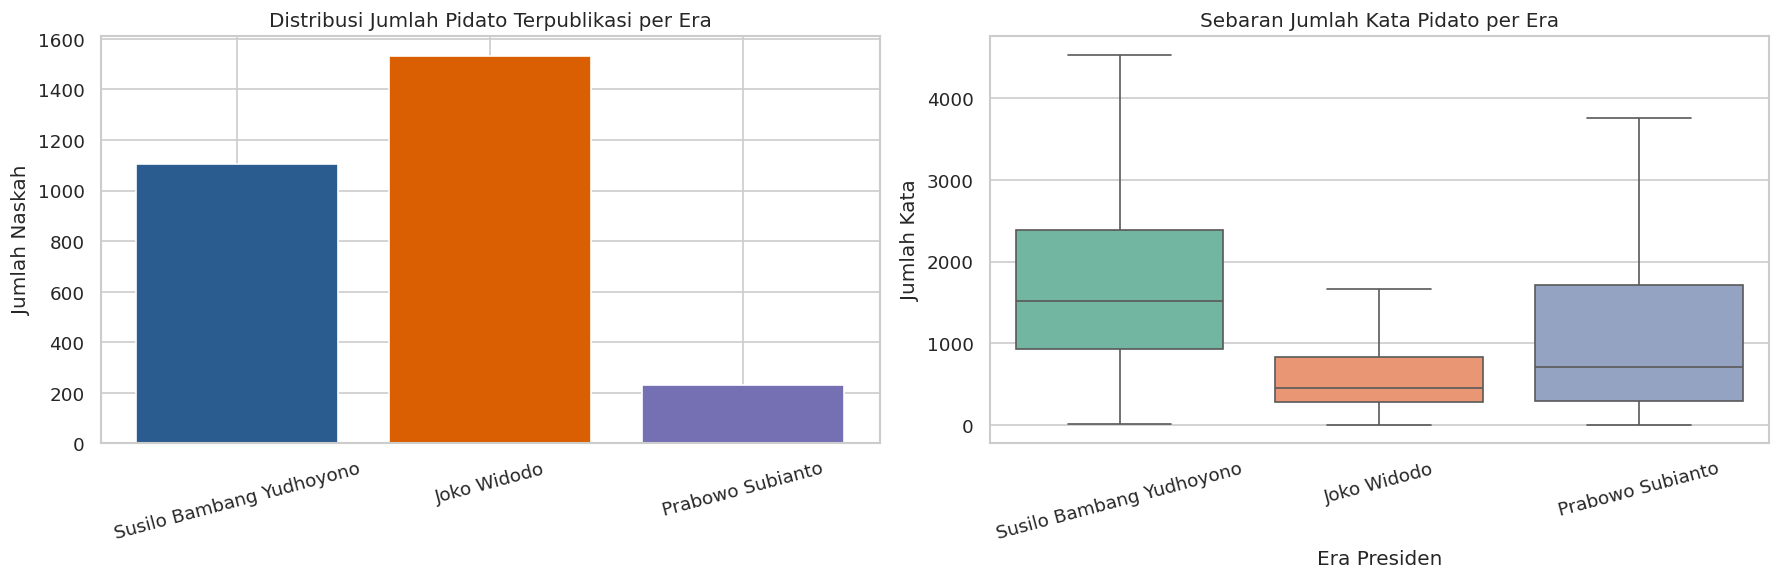

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Total Pidato per Era
era_counts = (
    df_speech["president_era"]
    .value_counts(dropna=False)
    .reindex(labels + [np.nan])
)
axes[0].bar(
    [str(x) if pd.notna(x) else "Tidak Diketahui" for x in era_counts.index],
    era_counts.values,
    color=["#2b5c8f", "#d95f02", "#7570b3", "#999999"],
)
axes[0].set_title("Distribusi Jumlah Pidato Terpublikasi per Era")
axes[0].set_ylabel("Jumlah Naskah")
axes[0].tick_params(axis="x", rotation=15)

# 2. Distribusi Panjang Pidato (Kata) tanpa terdistorsi outlier ekstrem (pakai log scale atau boxplot)
sns.boxplot(
    data=df_speech[df_speech["content_word_count"] > 0],
    x="president_era",
    y="content_word_count",
    hue="president_era",
    legend=False,
    ax=axes[1],
    palette="Set2",
    showfliers=False,
)
axes[1].set_title("Sebaran Jumlah Kata Pidato per Era")
axes[1].set_xlabel("Era Presiden")
axes[1].set_ylabel("Jumlah Kata")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

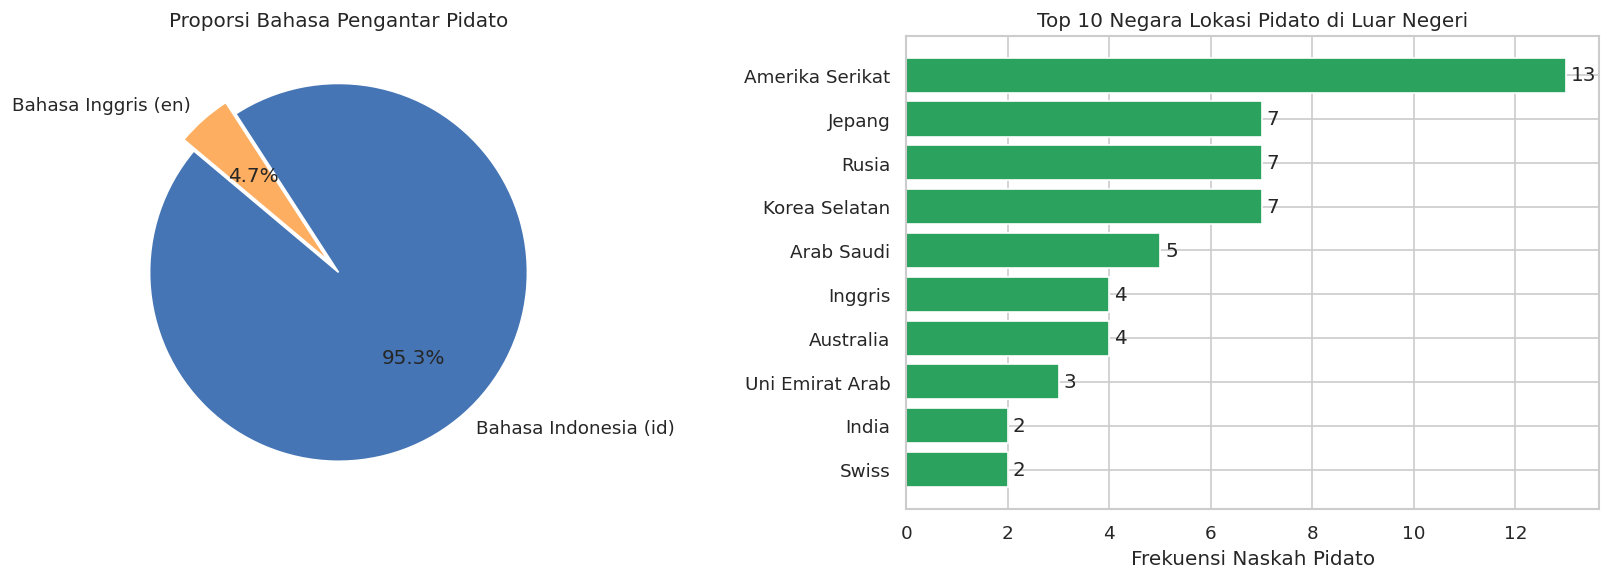

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Rasio Bahasa
lang_summary = df_speech["language"].value_counts()
axes[0].pie(
    lang_summary,
    labels=[
        "Bahasa Indonesia (id)" if k == "id" else "Bahasa Inggris (en)"
        for k in lang_summary.index
    ],
    autopct="%1.1f%%",
    startangle=140,
    colors=["#4575b4", "#fdae61"],
    explode=[0, 0.08],
)
axes[0].set_title("Proporsi Bahasa Pengantar Pidato")

# 2. Top 10 Destinasi Luar Negeri
intl_df = (
    df_speech[
        df_speech["country"].notna()
        & (~df_speech["country"].isin(["Indonesia", "Internasional Lainnya"]))
    ]["country"]
    .value_counts()
    .head(10)
)

bars = axes[1].barh(intl_df.index, intl_df.values, color="#2ca25f")
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Negara Lokasi Pidato di Luar Negeri")
axes[1].set_xlabel("Frekuensi Naskah Pidato")
axes[1].set_ylabel("")
axes[1].bar_label(bars, padding=3)  # Tampilkan angka di ujung bar

plt.tight_layout()
plt.show()

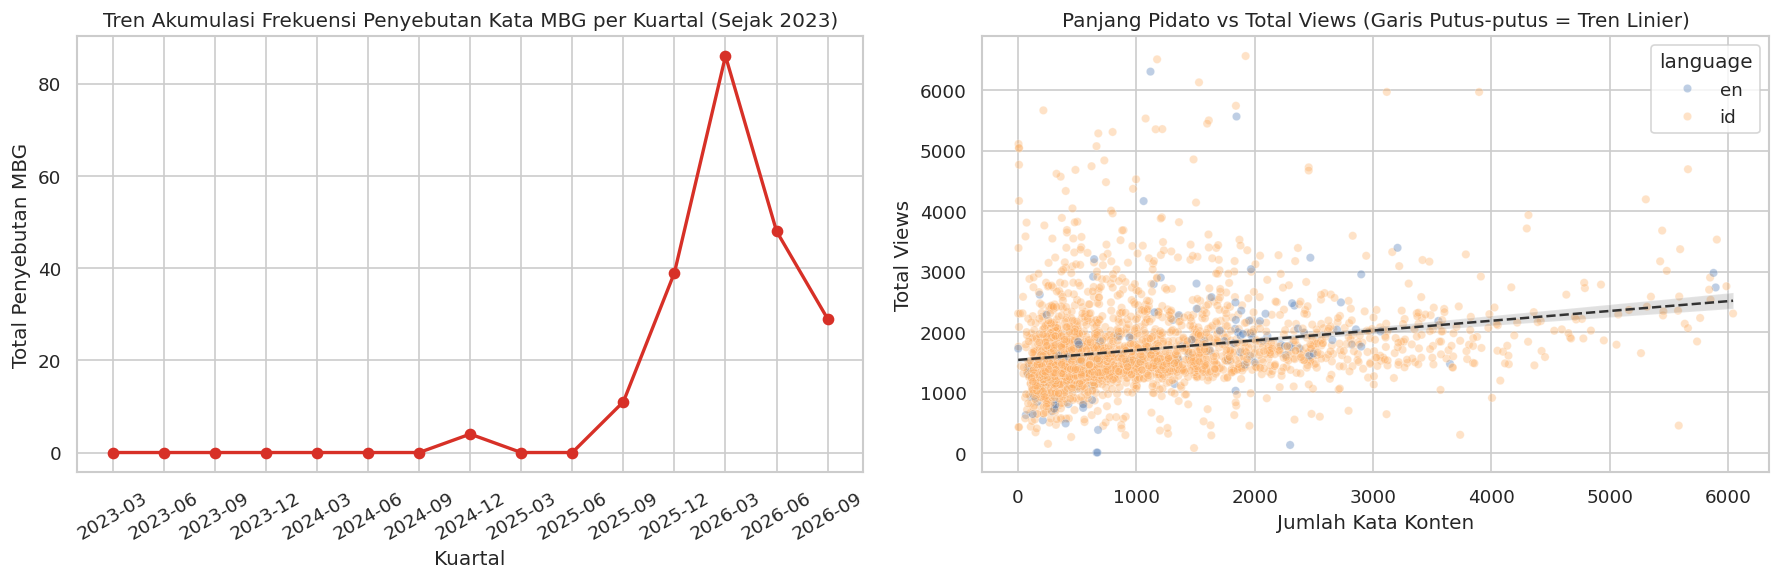

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Tren MBG (Mencakup data dari awal 2023 agar baseline 0 terlihat)
recent_speech = df_speech[df_speech["release_date"] >= "2023-01-01"].copy()
mbg_timeline = (
    recent_speech.set_index("release_date")
    .resample("QE")["mbg_mention_count"]
    .sum()
)

axes[0].plot(
    mbg_timeline.index.strftime("%Y-%m"),
    mbg_timeline.values,
    marker="o",
    color="#d73027",
    linewidth=2,
)
axes[0].set_title("Tren Akumulasi Frekuensi Penyebutan Kata MBG per Kuartal (Sejak 2023)")
axes[0].set_xlabel("Kuartal")
axes[0].set_ylabel("Total Penyebutan MBG")
axes[0].tick_params(axis="x", rotation=30)

# 2. Scatter Plot dengan Garis Regresi
q_views = df_speech["views_count"].quantile(0.99)
q_words = df_speech["content_word_count"].quantile(0.99)
clean_scatter = df_speech[
    (df_speech["views_count"] <= q_views)
    & (df_speech["content_word_count"] <= q_words)
    & (df_speech["content_word_count"] > 0)
]

sns.scatterplot(
    data=clean_scatter,
    x="content_word_count",
    y="views_count",
    hue="language",
    palette={"id": "#fdae61", "en": "#4575b4"},
    alpha=0.35,
    s=25,
    ax=axes[1],
)
sns.regplot(
    data=clean_scatter,
    x="content_word_count",
    y="views_count",
    scatter=False,
    ax=axes[1],
    color="#333333",
    line_kws={"linestyle": "--", "linewidth": 1.5},
)
axes[1].set_title(
    "Panjang Pidato vs Total Views (Garis Putus-putus = Tren Linier)"
)
axes[1].set_xlabel("Jumlah Kata Konten")
axes[1].set_ylabel("Total Views")

plt.tight_layout()
plt.show()

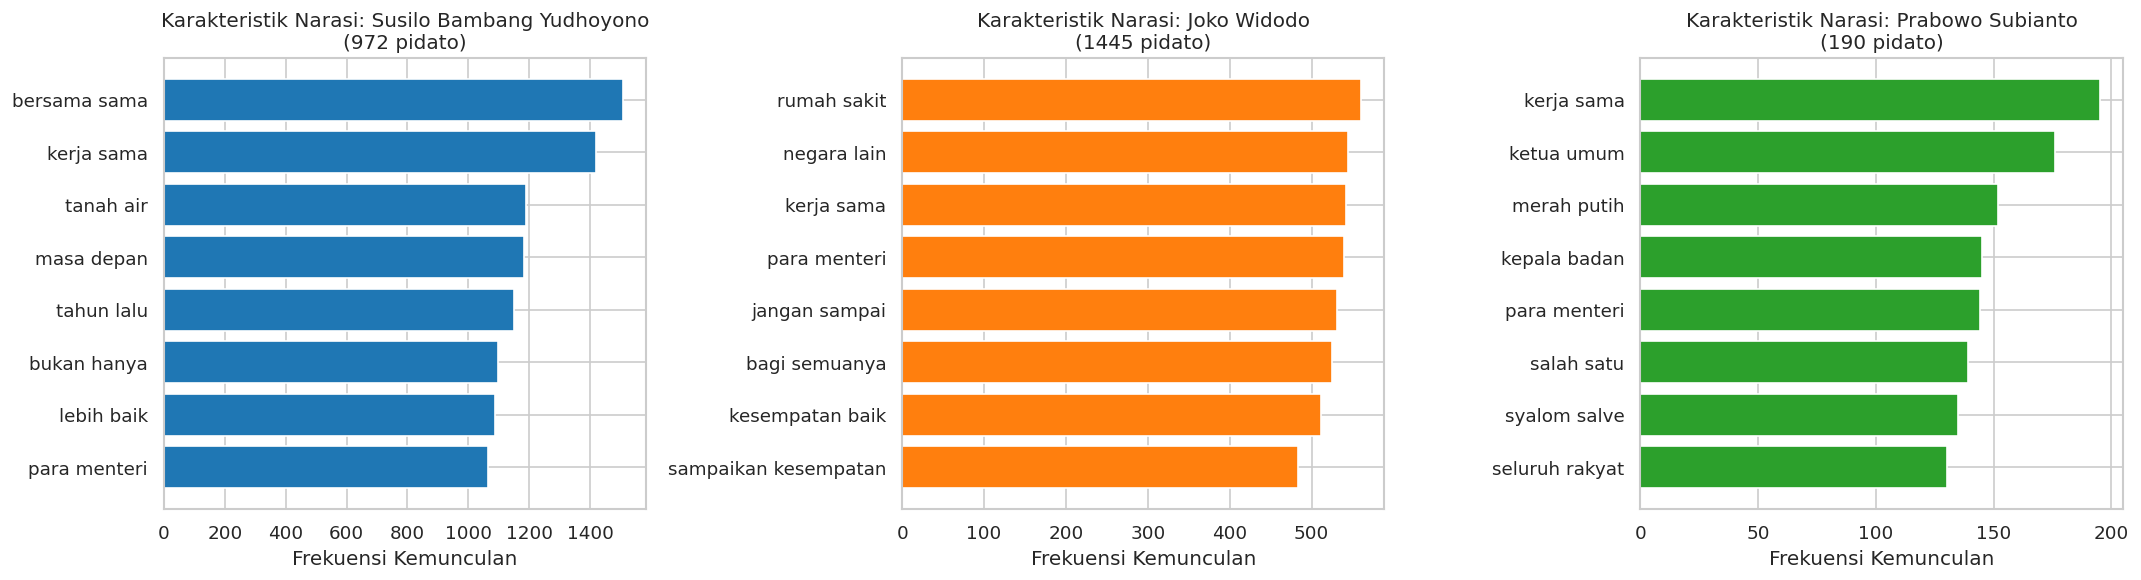

In [29]:
from collections import Counter
import re
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Stopwords naskah, filler, dan nama presiden
CUSTOM_STOPWORDS = {
    "yang",
    "dan",
    "di",
    "ke",
    "dari",
    "untuk",
    "pada",
    "ini",
    "itu",
    "dengan",
    "adalah",
    "saya",
    "kita",
    "akan",
    "juga",
    "bisa",
    "dalam",
    "ada",
    "tidak",
    "oleh",
    "harus",
    "sudah",
    "bapak",
    "ibu",
    "saudara",
    "hadirin",
    "sekalian",
    "hormat",
    "hormati",
    "assalamu",
    "alaikum",
    "assalamualaikum",
    "wassalamu",
    "warahmatullahi",
    "wabarakatuh",
    "salam",
    "sejahtera",
    "om",
    "shanti",
    "namo",
    "buddhaya",
    "terima",
    "kasih",
    "selamat",
    "pagi",
    "siang",
    "sore",
    "malam",
    "presiden",
    "republik",
    "indonesia",
    "sekali",
    "lagi",
    "insya",
    "allah",
    "luar",
    "biasa",
    "joko",
    "widodo",
    "jokowi",
    "prabowo",
    "subianto",
    "susilo",
    "bambang",
    "yudhoyono",
}


def extract_meaningful_bigrams(text_series, top_n=8):
  all_bigrams = []
  for text in text_series.dropna():
    words = [
        w
        for w in re.findall(r"\b[a-zA-Z]{3,}\b", text.lower())
        if w not in CUSTOM_STOPWORDS
    ]

    # Abaikan kata ulang (w1 == w2) seperti "negara negara" atau "hati hati"
    bigrams = [
        f"{words[i]} {words[i+1]}"
        for i in range(len(words) - 1)
        if words[i] != words[i + 1]
    ]
    all_bigrams.extend(bigrams)

  return Counter(all_bigrams).most_common(top_n)


df_id = df_speech[
    (df_speech["language"] == "id") & (df_speech["content_text"].str.len() > 50)
]
eras = ["Susilo Bambang Yudhoyono", "Joko Widodo", "Prabowo Subianto"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, era in enumerate(eras):
  era_texts = df_id[df_id["president_era"] == era]["content_text"]

  if len(era_texts) > 0:
    top_bigrams = extract_meaningful_bigrams(era_texts, top_n=8)
    if top_bigrams:
      phrases, counts = zip(*top_bigrams)
      axes[idx].barh(phrases, counts, color=sns.color_palette("tab10")[idx])
      axes[idx].invert_yaxis()
      axes[idx].set_title(
          f"Karakteristik Narasi: {era}\n({len(era_texts)} pidato)"
      )
      axes[idx].set_xlabel("Frekuensi Kemunculan")
  else:
    axes[idx].set_title(f"{era}\n(Data Belum Tersedia)")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()